In [1]:
import matplotlib.pyplot as plt
# %matplotlib notebook
# from ipywidgets import *
import numpy as np
import sys

In [2]:
import taurex.log
taurex.log.disableLogging()

In [3]:
from taurex.cache import OpacityCache,CIACache
from taurex.contributions import AbsorptionContribution, CIAContribution, RayleighContribution
from taurex.data.spectrum.observed import ObservedSpectrum
from taurex.model import TransmissionModel

from taurex.planet import Planet
from taurex.stellar import BlackbodyStar
from taurex.chemistry import TaurexChemistry, ConstantGas
from taurex.temperature import Isothermal

Numba not installed, using numpy instead


# Setup cache

In [4]:
xsec_path = "/Users/asweet/Code/research/taurex3/test_files/Input/xsec/xsec_sampled_R15000_0.3-50"
cia_path = "/Users/asweet/Code/research/taurex3/test_files/Input/cia/HITRAN/data"

OpacityCache().clear_cache()
OpacityCache().set_opacity_path(xsec_path)
CIACache().set_cia_path(cia_path)



# Define system objects

In [5]:
planet = Planet(planet_radius=1.0, planet_mass=1.0)
star = BlackbodyStar(temperature=5700.0, radius=1.0)

chemistry = TaurexChemistry(fill_gases=['H2','He'], ratio=0.172)
h2o = ConstantGas('H2O', mix_ratio=1.2e-4)
chemistry.addGas(h2o)
chemistry.addGas(ConstantGas('N2', mix_ratio=3.00739e-9))


# Define model

In [6]:
isothermal = Isothermal(T=1500.0)

tm = TransmissionModel(planet=planet,
                       temperature_profile=isothermal,
                       chemistry=chemistry,
                       star=star,
                       atm_min_pressure=1e-0,
                       atm_max_pressure=1e6,
                       nlayers=30)
tm.add_contribution(AbsorptionContribution())
tm.add_contribution(CIAContribution(cia_pairs=['H2-H2','H2-He']))
tm.add_contribution(RayleighContribution())
tm.build()

In [7]:
for key, val in tm._fitting_parameters.items():
    # * parameter name
    # * parameter name in Latex form
    # * get function
    # * set function
    # * fitting scale
    # * fit as default
    # * fitting boundaries
    get_val = val[2]()
    val_range = val[-1]
    fit_scale = val[4]
    print(key, get_val, val_range, fit_scale)

planet_mass 1.0 [0.5, 1.5] linear
planet_radius 1.0 [0.9, 1.1] linear
planet_distance 0.9999999999999999 [1, 2] linear
planet_sma 0.9999999999999999 [1, 2] linear
distance 1 [1, 22] linear
atm_min_pressure 1.0 [0.1, 1.0] log
atm_max_pressure 1000000.0 [0.1, 1.0] log
T 1500.0 [300.0, 2000.0] linear
H2O 0.00012 [1e-12, 0.1] log
N2 3.00739e-09 [1e-12, 0.1] log
He_H2 0.172 [1e-12, 0.1] log


In [8]:
for key, val in tm._derived_parameters.items():
    # * parameter name
    # * parameter name in Latex form
    # * get function
    # * set function
    # * fitting scale
    # * fit as default
    # * fitting boundaries
    get_val = val[2]()
    # val_range = val[-1]
    # fit_scale = val[4]
    print(key, get_val, val_range, fit_scale)

logg 1.3942155474041624 [1e-12, 0.1] log
avg_T 1500.0 [1e-12, 0.1] log
metallicity 0.0639549736683966 [1e-12, 0.1] log
mu 2.309331727200491 [1e-12, 0.1] log


In [13]:
# adjust gas
tm['H2O'] = 0.000077
tm['planet_radius'] = 0.975799
tm['T'] = 1742.901767


tm['H2O'] = 0.000075
tm['planet_radius'] = 0.977758
tm['T'] = 1657.852603

In [54]:
tm['H2O'] = 1e-4
tm['planet_radius'] = 0.9777810779205119
tm['T'] = 1496.606399794941

# Get Observations and bin them

In [14]:
# obs = ObservedSpectrum('path/to/test_data.dat')
obs = ObservedSpectrum('../test_files/quickstart.dat')

In [15]:
obin = obs.create_binner()

(tm) path_integral
(tm) path_integral, dz: [ 95753.07823596  96015.5871231   96279.17650657  96543.8523223
  96809.62054701  97076.48719859  97344.45833638  97613.54006157
  97883.73851753  98155.05989013  98427.51040815  98701.09634359
  98975.82401205  99251.69977309  99528.73003059  99806.92123315
 100086.27987442 100366.81249353 100648.52567542 100931.42605127
 101215.52029886 101500.81514298 101787.31735582 102075.03375738
 102363.97121585 102654.13664806 102945.53701987 103238.17934657
 103532.07069335 103827.21817567], total_layers: 30, wngrid_size: 29685, 
density_profile: [3.84359554e+25 2.42514483e+25 1.53016294e+25 9.65467548e+24
 6.09168840e+24 3.84359554e+24 2.42514483e+24 1.53016294e+24
 9.65467548e+23 6.09168840e+23 3.84359554e+23 2.42514483e+23
 1.53016294e+23 9.65467548e+22 6.09168840e+22 3.84359554e+22
 2.42514483e+22 1.53016294e+22 9.65467548e+21 6.09168840e+21
 3.84359554e+21 2.42514483e+21 1.53016294e+21 9.65467548e+20
 6.09168840e+20 3.84359554e+20 2.42514483e+20 

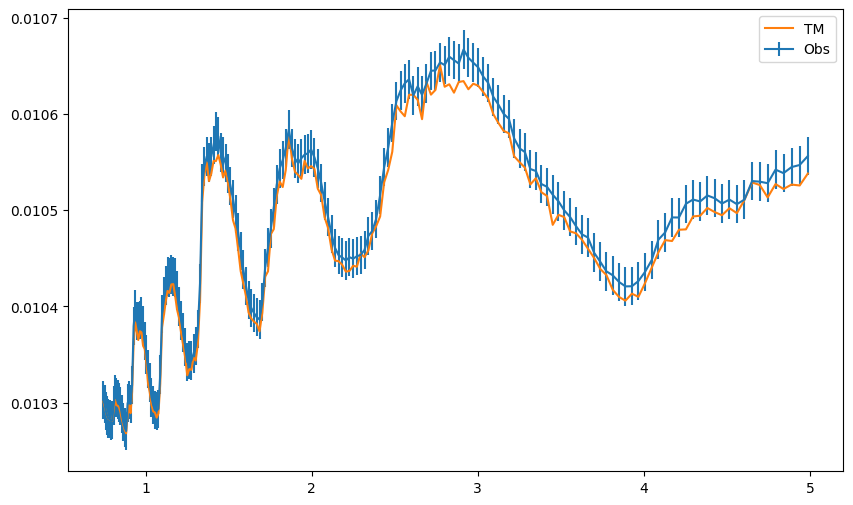

In [16]:
plt.figure(figsize=(10, 6))
plt.errorbar(obs.wavelengthGrid, obs.spectrum, obs.errorBar, label='Obs')
plt.plot(obs.wavelengthGrid, obin.bin_model(tm.model(obs.wavenumberGrid))[1], label='TM')
plt.legend()
plt.show()

# Fit with nestle

In [13]:
from taurex.optimizer.nestle import NestleOptimizer
opt = NestleOptimizer(num_live_points=50)

In [14]:
opt.set_model(tm)
opt.set_observed(obs)

### Set parameters to be fit, with bounds

In [15]:
opt.enable_fit('planet_radius')
opt.enable_fit('T')
opt.enable_fit('H2O')
opt.set_boundary('T', [1000, 2000])
opt.set_boundary('planet_radius', [0.8, 2.1])

In [16]:
opt.fit_names

['planet_radius', 'T', 'log_H2O']

In [17]:
solution = opt.fit()
taurex.log.disableLogging()

it=   813 logz=1875.674747niter: 814
ncall: 2685
nsamples: 864
logz: 1876.030 +/-  0.527
h: 13.913


In [18]:
opt.fit_names

['planet_radius', 'T', 'log_H2O']

In [40]:
np.log(1e-4)

-9.210340371976182

In [19]:
opt.fit_values

[0.9777810779205119, 1496.606399794941, -4.000667274630998]

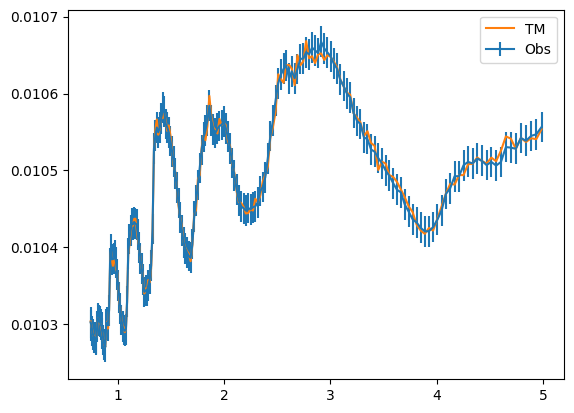

In [20]:
for solution,optimized_map,optimized_value,values in opt.get_solution():
    opt.update_model(optimized_map)
    plt.figure()
    plt.errorbar(obs.wavelengthGrid,obs.spectrum,obs.errorBar,label='Obs')
    plt.plot(obs.wavelengthGrid,obin.bin_model(tm.model(obs.wavenumberGrid))[1],label='TM')
    plt.legend()
    plt.show()